# Probability of Exceedance Plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
# dict for epochs
epochs = {
    'HIST': '/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*',
    '8p5END': '/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*',
    '4p5END': '/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*',
    '8p5MID': '/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*',
    '4p5MID': '/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*'
}

# dict to store dataframes
df_epochs = {}

In [3]:
# loop through each epoch, load files, apply threshold and datetime operations
for epoch, path in epochs.items():
    # load files
    df = pd.concat(map(pd.read_csv, glob.glob(path)), ignore_index=True)
    
    # thresholding
    df = df[(df['DBZ'] >= 40.0) & (df['UVV'] >= 25.0)]
    
    # convert to datetime
    df['Time'] = pd.to_datetime(df['Time'])
    df['Date'] = df['Time'].dt.date
    df['Year'] = df['Time'].dt.year
    df['Month'] = df['Time'].dt.month
    
    # store dataframe in dict
    df_epochs[epoch] = df

In [4]:
# function calcs probability of exceedance and percentile
def calculate_poe(data):
    """
    Calculate probability of exceedance for a given dataset.
    Args:
        data (array-like): Array of counts of HCW events.
    Returns:
        sorted_data: Sorted values of data (descending).
        poe: Probability of exceedance for each value in sorted_data.
    """
    sorted_data = np.sort(data)[::-1]  # sort in descending order
    n = len(sorted_data)
    ranks = np.arange(1, n + 1)
    poe = ranks / (n + 1)  # prob of exceedance formula
    
    # function to calc 90th percentile
    percentile_90 = data.quantile(0.9)
    # percentile_50 = data.quantile(0.5)
    
    return sorted_data, poe, percentile_90

In [5]:
# colors for each epoch
colors = {
    'HIST': '#c5eabc',
    '8p5MID': '#ca6e74',
    '4p5MID': '#b5d6ea',
    '8p5END': '#a51017',
    '4p5END': '#006db3'
}

## PoE Plot for HCW Event Counts per Day

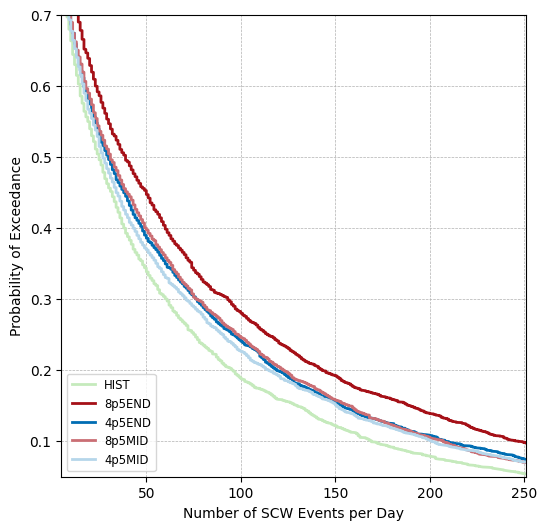

In [52]:
# plot POE curves
plt.figure(figsize=(6, 6))

# iterate over each epoch and plot POE curve for HCW event counts
for epoch, df in df_epochs.items():
    # count number of HCW events per day
    hcw_event_counts = df.groupby('Date').size()  # number of events per day
    
    # calc POE for these event counts
    sorted_data, poe, percentile_90 = calculate_poe(hcw_event_counts)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)
    
    # plot vertical dashed lines for 90th percentile
    # plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    
# plt.title('Probability of Exceedance for HCW Event Counts per Day', fontsize=14)
plt.xlabel('Number of SCW Events per Day', fontsize=10)
plt.ylabel('Probability of Exceedance', fontsize=10)
plt.legend(loc='lower left', fontsize='small')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0.05, 0.7)
plt.xlim(5, 251)
# plt.yscale('log')  # log scale for better vis

plt.savefig('../Plots/POE_CountsperDay4.jpg', format='jpg', dpi=500, bbox_inches='tight')

plt.show()

In [12]:
# print POE for specific event values per day
def print_poe(df_epochs, thresholds=[25, 50, 100, 150, 200, 250, 300]):
    """
    Print interpolated probability of exceedance for given HCW event thresholds for each epoch.

    Args:
        df_epochs (dict): Dictionary of dataframes by epoch.
        thresholds (list): List of event count thresholds to check PoE against.
    """
    print("Probability of Exceedance for Specified Thresholds:\n")
    for epoch, df in df_epochs.items():
        hcw_event_counts = df.groupby('Date').size()
        sorted_data, poe, _ = calculate_poe(hcw_event_counts)

        # Interpolation requires increasing x, so reverse arrays
        x = sorted_data[::-1]  # ascending
        y = poe[::-1]          # ascending

        print(f"Epoch: {epoch}")
        for threshold in thresholds:
            if threshold < x[0]:
                # threshold is below min count, so PoE = 1
                poe_value = 1.0
            elif threshold > x[-1]:
                # threshold is above max count, so PoE = 0
                poe_value = 0.0
            else:
                poe_value = np.interp(threshold, x, y)
            print(f"  Threshold {threshold:3d}: PoE = {poe_value:.3f}")
        print()

print_poe(df_epochs, thresholds=[25, 50, 100, 150, 200, 250, 300])

Probability of Exceedance for Specified Thresholds:

Epoch: HIST
  Threshold  25: PoE = 0.496
  Threshold  50: PoE = 0.338
  Threshold 100: PoE = 0.188
  Threshold 150: PoE = 0.122
  Threshold 200: PoE = 0.079
  Threshold 250: PoE = 0.054
  Threshold 300: PoE = 0.037

Epoch: 8p5END
  Threshold  25: PoE = 0.586
  Threshold  50: PoE = 0.447
  Threshold 100: PoE = 0.280
  Threshold 150: PoE = 0.192
  Threshold 200: PoE = 0.139
  Threshold 250: PoE = 0.098
  Threshold 300: PoE = 0.076

Epoch: 4p5END
  Threshold  25: PoE = 0.528
  Threshold  50: PoE = 0.386
  Threshold 100: PoE = 0.241
  Threshold 150: PoE = 0.154
  Threshold 200: PoE = 0.108
  Threshold 250: PoE = 0.075
  Threshold 300: PoE = 0.052

Epoch: 8p5MID
  Threshold  25: PoE = 0.536
  Threshold  50: PoE = 0.397
  Threshold 100: PoE = 0.246
  Threshold 150: PoE = 0.158
  Threshold 200: PoE = 0.105
  Threshold 250: PoE = 0.070
  Threshold 300: PoE = 0.048

Epoch: 4p5MID
  Threshold  25: PoE = 0.515
  Threshold  50: PoE = 0.369
  Thr

In [53]:
def print_mean_events_per_day(df_epochs):
    """
    Print the mean number of HCW events per day for each epoch.
    
    Args:
        df_epochs (dict): Dictionary of dataframes by epoch.
    """
    print("Mean Number of SCW Events per Day:\n")
    for epoch, df in df_epochs.items():
        daily_counts = df.groupby('Date').size()
        mean_events = daily_counts.mean()
        median_events = daily_counts.median()
        print(f"Epoch: {epoch:7s} | Mean Events/Day: {mean_events:.2f} | Median {median_events:.2f}")
        
print_mean_events_per_day(df_epochs)

Mean Number of SCW Events per Day:

Epoch: HIST    | Mean Events/Day: 62.26 | Median 25.00
Epoch: 8p5END  | Mean Events/Day: 92.45 | Median 39.00
Epoch: 4p5END  | Mean Events/Day: 76.56 | Median 30.00
Epoch: 8p5MID  | Mean Events/Day: 74.74 | Median 31.00
Epoch: 4p5MID  | Mean Events/Day: 71.94 | Median 27.00


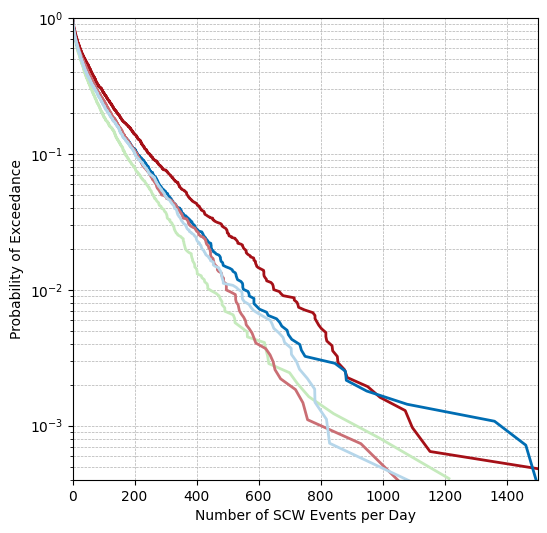

In [54]:
# plot POE curves LOG PLOT
plt.figure(figsize=(6, 6))

# iterate over each epoch and plot POE curve for HCW event counts
for epoch, df in df_epochs.items():
    # count number of HCW events per day
    hcw_event_counts = df.groupby('Date').size()  # number of events per day
    
    # calc POE for these event counts
    sorted_data, poe, percentile_90 = calculate_poe(hcw_event_counts)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)

    # plot vertical dashed lines for 90th and 50th percentiles
    # plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    # plt.axvline(x=percentile_50, color=colors[epoch], linestyle='dashed', label=f'50th Percentile ({percentile_50:.2f})')
    
# plt.title('Probability of Exceedance for HCW Event Counts per Day', fontsize=14)
plt.xlabel('Number of SCW Events per Day', fontsize=10)
plt.ylabel('Probability of Exceedance', fontsize=10)
# plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(0,1500)
plt.yscale('log')  # log scale for better vis
plt.ylim(4e-4, 1e0)

plt.savefig('../Plots/POE_CountsperDay_log2.jpg', format='jpg', dpi=500, bbox_inches='tight')

plt.show()

## PoE Plot for Count of HCW Events per Year

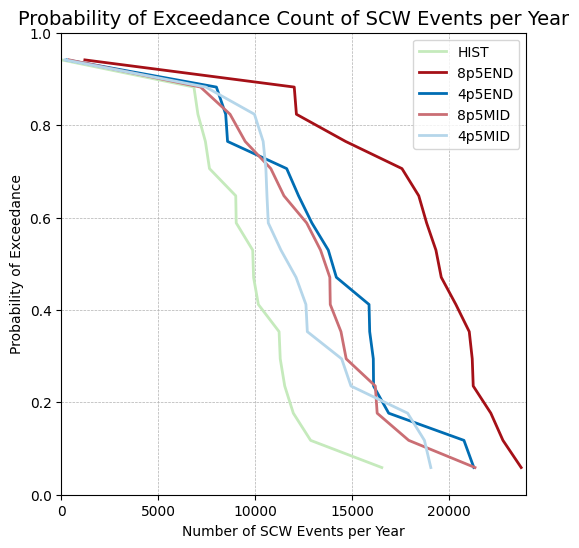

In [55]:
# POE curves for count of HCW events per year
plt.figure(figsize=(6, 6))
for epoch, df in df_epochs.items():
    # count number of HCW events per year
    hcw_event_counts_per_year = df.groupby('Year').size()
    
    # calc POE for yearly event counts
    sorted_data, poe, percentile_90 = calculate_poe(hcw_event_counts_per_year)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)

    # plot vertical dashed line for 90th percentile
    # plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    
plt.title('Probability of Exceedance Count of SCW Events per Year', fontsize=14)
plt.xlabel('Number of SCW Events per Year', fontsize=10)
plt.ylabel('Probability of Exceedance', fontsize=10)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 1.0)
plt.xlim(0, 24000)
# plt.yscale('log')

plt.savefig('../Plots/POE_CountsperYear.jpg', format='jpg', dpi=500, bbox_inches='tight')

plt.show()

## POE Plot of HCW Days per Year

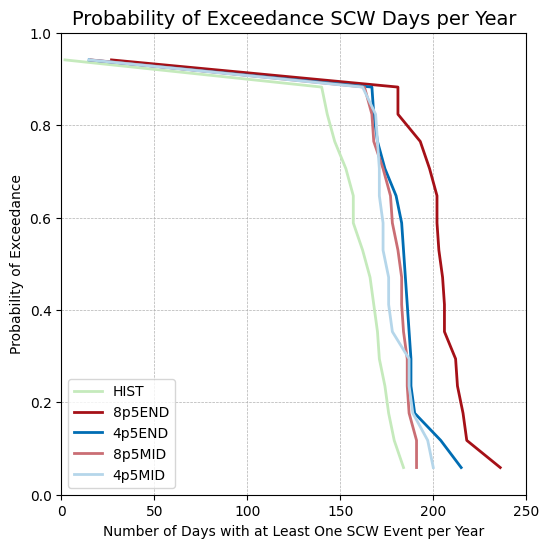

In [56]:
# POE curves for the number of days per year with at least one HCW event
plt.figure(figsize=(6, 6))
for epoch, df in df_epochs.items():
    # count number of days per year with at least one HCW event
    days_with_hcw_event_per_year = df.groupby(['Year', 'Date']).size().groupby('Year').apply(lambda x: (x > 0).sum())
    
    # calc POE for yearly day counts
    sorted_data, poe, percentile_90 = calculate_poe(days_with_hcw_event_per_year)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)

    # plot vertical dashed line for 90th percentile
    # plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    
plt.title('Probability of Exceedance SCW Days per Year', fontsize=14)
plt.xlabel('Number of Days with at Least One SCW Event per Year', fontsize=10)
plt.ylabel('Probability of Exceedance', fontsize=10)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0,1.0)
plt.xlim(0,250)
# plt.yscale('log')

plt.savefig('../Plots/POE_DaysperYear.jpg', format='jpg', dpi=500, bbox_inches='tight')

plt.show()